In [1]:
import pandas as pd
import numpy as np
import math as m

In [2]:
df = pd.read_csv('C:/Users/Acer/Documents/ISWAN DATAS/SINGLE LAYER PERCEPTRON/DATASET/Iris/iris3.csv')
df.head()

data = df.assign(
    y=df['Name'].map({'Iris-setosa': 0, 'Iris-versicolor':1}),
    w1=0, w2=0, w3=0, w4=0, bias=0, sum=0, activation=0, predict=0 ,error=0, dw1=0, dw2=0, dw3=0, dw4=0, dbias=0)
data.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name,y,w1,w2,w3,w4,bias,sum,activation,predict,error,dw1,dw2,dw3,dw4,dbias
0,5.1,3.5,1.4,0.2,Iris-setosa,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [3]:
sec1 = data[:10]
sec11 = data[90:100]
sec1 = sec1.append(sec11, ignore_index=True)

sec2 = data[10:20]
sec22 = data[80:90]
sec2 = sec2.append(sec22, ignore_index=True)

sec3 = data[20:30]
sec33 = data[70:80]
sec3 = sec3.append(sec33, ignore_index=True)

sec4 = data[30:40]
sec44 = data[60:70]
sec4 = sec4.append(sec44, ignore_index=True)

sec5 = data[40:50]
sec55 = data[50:60]
sec5 = sec5.append(sec55, ignore_index=True)

train1 = sec1.append(sec2, ignore_index=True)
train1 = train1.append(sec3, ignore_index=True)
train1 = train1.append(sec4, ignore_index=True)

train2 = sec2.append(sec3, ignore_index=True)
train2 = train2.append(sec4, ignore_index=True)
train2 = train2.append(sec5, ignore_index=True)

train3 = sec3.append(sec4, ignore_index=True)
train3 = train3.append(sec5, ignore_index=True)
train3 = train3.append(sec1, ignore_index=True)

train4 = sec4.append(sec5, ignore_index=True)
train4 = train4.append(sec1, ignore_index=True)
train4 = train4.append(sec2, ignore_index=True)

train5 = sec5.append(sec1, ignore_index=True)
train5 = train5.append(sec2, ignore_index=True)
train5 = train5.append(sec3, ignore_index=True)

C:\Users\Acer\AppData\Local\Temp\ipykernel_14880\1121372335.py:3: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  sec1 = sec1.append(sec11, ignore_index=True)
C:\Users\Acer\AppData\Local\Temp\ipykernel_14880\1121372335.py:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  sec2 = sec2.append(sec22, ignore_index=True)
C:\Users\Acer\AppData\Local\Temp\ipykernel_14880\1121372335.py:11: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  sec3 = sec3.append(sec33, ignore_index=True)
C:\Users\Acer\AppData\Local\Temp\ipykernel_14880\1121372335.py:15: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  sec4 = sec4.append(sec44, ignore_index=True)
C:\Users\Acer\

In [4]:
def resultsum(x, weight, bias, w_bias):
    resultsum = np.dot(x, weight) + (bias * w_bias)
    return resultsum

def activation(resultsum):
    aktivasi = 1 / (1 + m.exp(-resultsum))
    return aktivasi

def predict(f):
    if f > 0.5:
        return 1
    else:
        return 0

def error(f, target):
    error = 1 / 2 * (pow((f - target), 2))
    return error

def dT(x, f, target):
    dt = 2 * (f - target) * (1 - f) * (f * x)
    return dt

def updateweight(dt, weight, learning_rate):
    weight = weight - (learning_rate * dt)
    return weight

def updatebias(dt, bias, learning_rate):
    bias = bias - (learning_rate * dt)
    return bias

def akurasi(pred, target):
    TP = 0.0
    TN = 0.0
    FP = 0.0
    FN = 0.0

    for i in range(len(target)):

        if target.iloc[i] == 1.0 and pred.iloc[i] == 1.0:
            TP = TP + 1.0

        elif target.iloc[i] == 1.0 and pred.iloc[i] == 0.0:
            FN = FN + 1.0

        elif target.iloc[i] == 0.0 and pred.iloc[i] == 0.0:
            TN = TN + 1.0

        elif target.iloc[i] == 0.0 and pred.iloc[i] == 1.0:
            FP = FP + 1.0

    hitung_akurasi = (TP + TN) / (TP + TN + FP + FN)

    return hitung_akurasi

In [5]:
kunci1 = sec1['y']
kunci2 = sec2['y']
kunci3 = sec3['y']
kunci4 = sec4['y']
kunci5 = sec5['y']

kunciT1 = train1['y']
kunciT2 = train2['y']
kunciT3 = train3['y']
kunciT4 = train4['y']
kunciT5 = train5['y']

### FOLD 1 : TRAIN = train1, validation = sec5

In [6]:
bias = 0.5

plot_error1 = np.zeros(300)
plot_akurasi1 = np.zeros(300)
plot_error1v = np.zeros(300)
plot_akurasi1v = np.zeros(300)

for k in range(300):

    for i in range(0, 80):

        x = train1.loc[i, 'SepalLength':'PetalWidth']


# DATA PERTAMA PADA EPOCH PERTAMA

        if i == 0 and k == 0:

            weight = [0.5, 0.5, 0.5, 0.5]

            train1['w1'][i] = weight[0]
            train1['w2'][i] = weight[1]
            train1['w3'][i] = weight[2]
            train1['w4'][i] = weight[3]

            train1['bias'][i] = bias

            train1['sum'][i] = resultsum(
                x,
                weight,
                bias,
                1
            )

            train1['activation'][i] = activation(
                train1['sum'][i]
            )
            train1['predict'][i] = predict(
                train1['activation'][i]
            )
            train1['error'][i] = error(
                train1['activation'][i],
                train1['y'][i]
            )
            train1['dw1'][i] = dT(
                x[0],
                train1['activation'][i],
                train1['y'][i]
            )
            train1['dw2'][i] = dT(
                x[1],
                train1['activation'][i],
                train1['y'][i]
            )
            train1['dw3'][i] = dT(
                x[2],
                train1['activation'][i],
                train1['y'][i]
            )
            train1['dw4'][i] = dT(
                x[3],
                train1['activation'][i],
                train1['y'][i]
            )
            train1['dbias'][i] = dT(
                1,
                train1['activation'][i],
                train1['y'][i]
            )

        elif i > 0:

            train1['w1'][i] = updateweight(
                train1['dw1'][i-1],
                train1['w1'][i-1],
                0.1
            )
            train1['w2'][i] = updateweight(
                train1['dw2'][i-1],
                train1['w2'][i-1],
                0.1
            )
            train1['w3'][i] = updateweight(
                train1['dw3'][i-1],
                train1['w3'][i-1],
                0.1
            )

            train1['w4'][i] = updateweight(
                train1['dw4'][i-1],
                train1['w4'][i-1],
                0.1
            )
            train1['bias'][i] = updatebias(
                train1['dbias'][i-1],
                train1['bias'][i-1],
                0.1
            )
            weight = [
                train1['w1'][i],
                train1['w2'][i],
                train1['w3'][i],
                train1['w4'][i]
            ]
            train1['sum'][i] = resultsum(
                x,
                weight,
                train1['bias'][i],
                1
            )
            train1['activation'][i] = activation(
                train1['sum'][i]
            )
            train1['predict'][i] = predict(
                train1['activation'][i]
            )
            train1['error'][i] = error(
                train1['activation'][i],
                train1['y'][i]
            )
            train1['dw1'][i] = dT(
                x[0],
                train1['activation'][i],
                train1['y'][i]
            )
            train1['dw2'][i] = dT(
                x[1],
                train1['activation'][i],
                train1['y'][i]
            )
            train1['dw3'][i] = dT(
                x[2],
                train1['activation'][i],
                train1['y'][i]
            )
            train1['dw4'][i] = dT(
                x[3],
                train1['activation'][i],
                train1['y'][i]
            )
            train1['dbias'][i] = dT(
                1,
                train1['activation'][i],
                train1['y'][i]
            )

        elif i == 0 and k > 0:
            train1['w1'][i] = updateweight(
                train1['dw1'][79],
                train1['w1'][79],
                0.1
            )
            train1['w2'][i] = updateweight(
                train1['dw2'][79],
                train1['w2'][79],
                0.1
            )
            train1['w3'][i] = updateweight(
                train1['dw3'][79],
                train1['w3'][79],
                0.1
            )
            train1['w4'][i] = updateweight(
                train1['dw4'][79],
                train1['w4'][79],
                0.1
            )
            train1['bias'][i] = updatebias(
                train1['dbias'][79],
                train1['bias'][79],
                0.1
            )
            weight = [
                train1['w1'][i],
                train1['w2'][i],
                train1['w3'][i],
                train1['w4'][i]
            ]
            train1['sum'][i] = resultsum(
                x,
                weight,
                train1['bias'][i],
                1
            )
            train1['activation'][i] = activation(
                train1['sum'][i]
            )
            train1['predict'][i] = predict(
                train1['activation'][i]
            )
            train1['error'][i] = error(
                train1['activation'][i],
                train1['y'][i]
            )
            train1['dw1'][i] = dT(
                x[0],
                train1['activation'][i],
                train1['y'][i]
            )
            train1['dw2'][i] = dT(
                x[1],
                train1['activation'][i],
                train1['y'][i]
            )
            train1['dw3'][i] = dT(
                x[2],
                train1['activation'][i],
                train1['y'][i]
            )
            train1['dw4'][i] = dT(
                x[3],
                train1['activation'][i],
                train1['y'][i]
            )
            train1['dbias'][i] = dT(
                1,
                train1['activation'][i],
                train1['y'][i]
            )


# Hasil Training setelah 80 data selesai
    plot_error1[k] = (
        sum(train1['error'])
    ) / 80

    plot_akurasi1[k] = akurasi(
        train1['predict'],
        kunciT1
    )

#validasi menggunakan sec5
    for j in range(20):

        x = sec5.loc[
            j,
            'SepalLength':'PetalWidth'
        ]
        weight = [
            train1.w1[79],
            train1.w2[79],
            train1.w3[79],
            train1.w4[79]
        ]
        sec5['w1'][j] = weight[0]
        sec5['w2'][j] = weight[1]
        sec5['w3'][j] = weight[2]
        sec5['w4'][j] = weight[3]

        sec5['bias'][j] = train1['bias'][79]

        sec5['sum'][j] = resultsum(
            x,
            weight,
            train1['bias'][79],
            1
        )
        sec5['activation'][j] = activation(
            sec5['sum'][j]
        )
        sec5['predict'][j] = predict(
            sec5['activation'][j]
        )
        sec5['error'][j] = error(
            sec5['activation'][j],
            sec5['y'][j]
        )

# Hasil validasi setelah 20 data selesai
    plot_error1v[k] = (
        sum(sec5['error'])
    ) / 20

    plot_akurasi1v[k] = akurasi(
        sec5['predict'],
        kunci5
    )



C:\Users\Acer\AppData\Local\Temp\ipykernel_14880\3465483397.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train1['w1'][i] = weight[0]
C:\Users\Acer\AppData\Local\Temp\ipykernel_14880\3465483397.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train1['w2'][i] = weight[1]
C:\Users\Acer\AppData\Local\Temp\ipykernel_14880\3465483397.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train1['w3'][i] = weight[2]
C:\Users\Acer\Ap

#### FOLD 2: TRAIN = train2, validation = sec1

In [7]:
bias = 0.5
plot_error2 = np.zeros(300)
plot_akurasi2 = np.zeros(300)
plot_error2v = np.zeros(300)
plot_akurasi2v = np.zeros(300)

for k in range(300):
    for i in range(0, 80):
        x = train2.loc[i, 'SepalLength':'PetalWidth']

       
#Data pertama pada epoch pertama
        if i == 0 and k == 0:
            weight = [0.5, 0.5, 0.5, 0.5]
            train2['w1'][i] = weight[0]
            train2['w2'][i] = weight[1]
            train2['w3'][i] = weight[2]
            train2['w4'][i] = weight[3]
            train2['bias'][i] = bias
            train2['sum'][i] = resultsum(
                x,
                weight,
                bias,
                1
            )
            train2['activation'][i] = activation(
                train2['sum'][i]
            )
            train2['predict'][i] = predict(
                train2['activation'][i]
            )
            train2['error'][i] = error(
                train2['activation'][i],
                train2['y'][i]
            )
            train2['dw1'][i] = dT(
                x[0],
                train2['activation'][i],
                train2['y'][i]
            )
            train2['dw2'][i] = dT(
                x[1],
                train2['activation'][i],
                train2['y'][i]
            )
            train2['dw3'][i] = dT(
                x[2],
                train2['activation'][i],
                train2['y'][i]
            )
            train2['dw4'][i] = dT(
                x[3],
                train2['activation'][i],
                train2['y'][i]
            )
            train2['dbias'][i] = dT(
                1,
                train2['activation'][i],
                train2['y'][i]
            )

#Data ke-2 sampai data ke 80
        elif i > 0:
            train2['w1'][i] = updateweight(
                train2['dw1'][i-1],
                train2['w1'][i-1],
                0.1
            )
            train2['w2'][i] = updateweight(
                train2['dw2'][i-1],
                train2['w2'][i-1],
                0.1
            )
            train2['w3'][i] = updateweight(
                train2['dw3'][i-1],
                train2['w3'][i-1],
                0.1
            )
            train2['w4'][i] = updateweight(
                train2['dw4'][i-1],
                train2['w4'][i-1],
                0.1
            )
            train2['bias'][i] = updatebias(
                train2['dbias'][i-1],
                train2['bias'][i-1],
                0.1
            )
            weight = [
                train2['w1'][i],
                train2['w2'][i],
                train2['w3'][i],
                train2['w4'][i]
            ]
            train2['sum'][i] = resultsum(
                x,
                weight,
                train2['bias'][i],
                1
            )
            train2['activation'][i] = activation(
                train2['sum'][i]
            )

            train2['predict'][i] = predict(
                train2['activation'][i]
            )
            train2['error'][i] = error(
                train2['activation'][i],
                train2['y'][i]
            )
            train2['dw1'][i] = dT(
                x[0],
                train2['activation'][i],
                train2['y'][i]
            )
            train2['dw2'][i] = dT(
                x[1],
                train2['activation'][i],
                train2['y'][i]
            )
            train2['dw3'][i] = dT(
                x[2],
                train2['activation'][i],
                train2['y'][i]
            )
            train2['dw4'][i] = dT(
                x[3],
                train2['activation'][i],
                train2['y'][i]
            )
            train2['dbias'][i] = dT(
                1,
                train2['activation'][i],
                train2['y'][i]
            )

#Data pertama pada epoch berikutnya 
        elif i == 0 and k > 0:
            train2['w1'][i] = updateweight(
                train2['dw1'][79],
                train2['w1'][79],
                0.1
            )
            train2['w2'][i] = updateweight(
                train2['dw2'][79],
                train2['w2'][79],
                0.1
            )
            train2['w3'][i] = updateweight(
                train2['dw3'][79],
                train2['w3'][79],
                0.1
            )
            train2['w4'][i] = updateweight(
                train2['dw4'][79],
                train2['w4'][79],
                0.1
            )
            train2['bias'][i] = updatebias(
                train2['dbias'][79],
                train2['bias'][79],
                0.1
            )
            weight = [
                train2['w1'][i],
                train2['w2'][i],
                train2['w3'][i],
                train2['w4'][i]
            ]
            train2['sum'][i] = resultsum(
                x,
                weight,
                train2['bias'][i],
                1
            )
            train2['activation'][i] = activation(
                train2['sum'][i]
            )
            train2['predict'][i] = predict(
                train2['activation'][i]
            )
            train2['error'][i] = error(
                train2['activation'][i],
                train2['y'][i]
            )
            train2['dw1'][i] = dT(
                x[0],
                train2['activation'][i],
                train2['y'][i]
            )
            train2['dw2'][i] = dT(
                x[1],
                train2['activation'][i],
                train2['y'][i]
            )
            train2['dw3'][i] = dT(
                x[2],
                train2['activation'][i],
                train2['y'][i]
            )
            train2['dw4'][i] = dT(
                x[3],
                train2['activation'][i],
                train2['y'][i]
            )
            train2['dbias'][i] = dT(
                1,
                train2['activation'][i],
                train2['y'][i]
            )

#Hasil training setelah 80 data selesai
    plot_error2[k] = (
        sum(train2['error'])
    ) / 80

    plot_akurasi2[k] = akurasi(
        train2['predict'],
        kunciT2
    )

#Validasi menggunakan sec1
    for j in range(20):
        x = sec1.loc[
            j,
            'SepalLength':'PetalWidth'
        ]
        weight = [
            train2.w1[79],
            train2.w2[79],
            train2.w3[79],
            train2.w4[79]
        ]
        sec1['w1'][j] = weight[0]
        sec1['w2'][j] = weight[1]
        sec1['w3'][j] = weight[2]
        sec1['w4'][j] = weight[3]
        sec1['bias'][j] = train2['bias'][79]
        sec1['sum'][j] = resultsum(
            x,
            weight,
            train2['bias'][79],
            1
        )
        sec1['activation'][j] = activation(
            sec1['sum'][j]
        )
        sec1['predict'][j] = predict(
            sec1['activation'][j]
        )
        sec1['error'][j] = error(
            sec1['activation'][j],
            sec1['y'][j]
        )

#Hasil validasi setelah 20 data selesai
    plot_error2v[k] = (
        sum(sec1['error'])
    ) / 20
    plot_akurasi2v[k] = akurasi(
        sec1['predict'],
        kunci1
    )


C:\Users\Acer\AppData\Local\Temp\ipykernel_14880\482795137.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['w1'][i] = weight[0]
C:\Users\Acer\AppData\Local\Temp\ipykernel_14880\482795137.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['w2'][i] = weight[1]
C:\Users\Acer\AppData\Local\Temp\ipykernel_14880\482795137.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['w3'][i] = weight[2]
C:\Users\Acer\AppDa

#### FOLD 3: TRAIN = train3, Validation = sec2

In [8]:
bias = 0.5
plot_error3 = np.zeros(300)
plot_akurasi3 = np.zeros(300)
plot_error3v = np.zeros(300)
plot_akurasi3v = np.zeros(300)

for k in range(300):
    for i in range(0, 80):
        x = train3.loc[i, 'SepalLength':'PetalWidth']

#Data pertama yang tedapat pada epoch pertama 
        if i == 0 and k == 0:
            weight = [0.5, 0.5, 0.5, 0.5]
            train3['w1'][i] = weight[0]
            train3['w2'][i] = weight[1]
            train3['w3'][i] = weight[2]
            train3['w4'][i] = weight[3]
            train3['bias'][i] = bias
            train3['sum'][i] = resultsum(
                x,
                weight,
                bias,
                1
            )
            train3['activation'][i] = activation(
                train3['sum'][i]
            )
            train3['predict'][i] = predict(
                train3['activation'][i]
            )
            train3['error'][i] = error(
                train3['activation'][i],
                train3['y'][i]
            )
            train3['dw1'][i] = dT(
                x[0],
                train3['activation'][i],
                train3['y'][i]
            )
            train3['dw2'][i] = dT(
                x[1],
                train3['activation'][i],
                train3['y'][i]
            )
            train3['dw3'][i] = dT(
                x[2],
                train3['activation'][i],
                train3['y'][i]
            )
            train3['dw4'][i] = dT(
                x[3],
                train3['activation'][i],
                train3['y'][i]
            )
            train3['dbias'][i] = dT(
                1,
                train3['activation'][i],
                train3['y'][i]
            )

        elif i > 0:
            train3['w1'][i] = updateweight(
                train3['dw1'][i-1],
                train3['w1'][i-1],
                0.1
            )
            train3['w2'][i] = updateweight(
                train3['dw2'][i-1],
                train3['w2'][i-1],
                0.1
            )
            train3['w3'][i] = updateweight(
                train3['dw3'][i-1],
                train3['w3'][i-1],
                0.1
            )
            train3['w4'][i] = updateweight(
                train3['dw4'][i-1],
                train3['w4'][i-1],
                0.1
            )
            train3['bias'][i] = updatebias(
                train3['dbias'][i-1],
                train3['bias'][i-1],
                0.1
            )
            weight = [
                train3['w1'][i],
                train3['w2'][i],
                train3['w3'][i],
                train3['w4'][i]
            ]
            train3['sum'][i] = resultsum(
                x,
                weight,
                train3['bias'][i],
                1
            )
            train3['activation'][i] = activation(
                train3['sum'][i]
            )
            train3['predict'][i] = predict(
                train3['activation'][i]
            )
            train3['error'][i] = error(
                train3['activation'][i],
                train3['y'][i]
            )
            train3['dw1'][i] = dT(
                x[0],
                train3['activation'][i],
                train3['y'][i]
            )
            train3['dw2'][i] = dT(
                x[1],
                train3['activation'][i],
                train3['y'][i]
            )
            train3['dw3'][i] = dT(
                x[2],
                train3['activation'][i],
                train3['y'][i]
            )
            train3['dw4'][i] = dT(
                x[3],
                train3['activation'][i],
                train3['y'][i]
            )
            train3['dbias'][i] = dT(
                1,
                train3['activation'][i],
                train3['y'][i]
            )

        elif i == 0 and k > 0:
            train3['w1'][i] = updateweight(
                train3['dw1'][79],
                train3['w1'][79],
                0.1
            )
            train3['w2'][i] = updateweight(
                train3['dw2'][79],
                train3['w2'][79],
                0.1
            )
            train3['w3'][i] = updateweight(
                train3['dw3'][79],
                train3['w3'][79],
                0.1
            )
            train3['w4'][i] = updateweight(
                train3['dw4'][79],
                train3['w4'][79],
                0.1
            )
            train3['bias'][i] = updatebias(
                train3['dbias'][79],
                train3['bias'][79],
                0.1
            )
            weight = [
                train3['w1'][i],
                train3['w2'][i],
                train3['w3'][i],
                train3['w4'][i]
            ]
            train3['sum'][i] = resultsum(
                x,
                weight,
                train3['bias'][i],
                1
            )
            train3['activation'][i] = activation(
                train3['sum'][i]
            )
            train3['predict'][i] = predict(
                train3['activation'][i]
            )
            train3['error'][i] = error(
                train3['activation'][i],
                train3['y'][i]
            )
            train3['dw1'][i] = dT(
                x[0],
                train3['activation'][i],
                train3['y'][i]
            )
            train3['dw2'][i] = dT(
                x[1],
                train3['activation'][i],
                train3['y'][i]
            )
            train3['dw3'][i] = dT(
                x[2],
                train3['activation'][i],
                train3['y'][i]
            )
            train3['dw4'][i] = dT(
                x[3],
                train3['activation'][i],
                train3['y'][i]
            )
            train3['dbias'][i] = dT(
                1,
                train3['activation'][i],
                train3['y'][i]
            )

    plot_error3[k] = (
        sum(train3['error'])
    ) / 80

    plot_akurasi3[k] = akurasi(
        train3['predict'],
        kunciT3
    )

    for j in range(20):
        x = sec2.loc[
            j,
            'SepalLength':'PetalWidth'
        ]
        weight = [
            train3.w1[79],
            train3.w2[79],
            train3.w3[79],
            train3.w4[79]
        ]
        sec2['w1'][j] = weight[0]
        sec2['w2'][j] = weight[1]
        sec2['w3'][j] = weight[2]
        sec2['w4'][j] = weight[3]
        sec2['bias'][j] = train3['bias'][79]
        sec2['sum'][j] = resultsum(
            x,
            weight,
            train3['bias'][79],
            1
        )
        sec2['activation'][j] = activation(
            sec2['sum'][j]
        )
        sec2['predict'][j] = predict(
            sec2['activation'][j]
        )
        sec2['error'][j] = error(
            sec2['activation'][j],
            sec2['y'][j]
        )
    plot_error3v[k] = (
        sum(sec2['error'])
    ) / 20

    plot_akurasi3v[k] = akurasi(
        sec2['predict'],
        kunci2
    )

C:\Users\Acer\AppData\Local\Temp\ipykernel_14880\3367625887.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train3['w1'][i] = weight[0]
C:\Users\Acer\AppData\Local\Temp\ipykernel_14880\3367625887.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train3['w2'][i] = weight[1]
C:\Users\Acer\AppData\Local\Temp\ipykernel_14880\3367625887.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train3['w3'][i] = weight[2]
C:\Users\Acer\Ap

FOLD 4: TRAIN = train4, validation = sec3

In [9]:
bias = 0.5
plot_error4 = np.zeros(300)
plot_akurasi4 = np.zeros(300)
plot_error4v = np.zeros(300)
plot_akurasi4v = np.zeros(300)

for k in range(300):
    for i in range(0, 80):
        x = train4.loc[i, 'SepalLength':'PetalWidth']
        if i == 0 and k == 0:
            weight = [0.5, 0.5, 0.5, 0.5]
            train4['w1'][i] = weight[0]
            train4['w2'][i] = weight[1]
            train4['w3'][i] = weight[2]
            train4['w4'][i] = weight[3]
            train4['bias'][i] = bias
            train4['sum'][i] = resultsum(
                x,
                weight,
                bias,
                1
            )
            train4['activation'][i] = activation(
                train4['sum'][i]
            )
            train4['predict'][i] = predict(
                train4['activation'][i]
            )
            train4['error'][i] = error(
                train4['activation'][i],
                train4['y'][i]
            )
            train4['dw1'][i] = dT(
                x[0],
                train4['activation'][i],
                train4['y'][i]
            )
            train4['dw2'][i] = dT(
                x[1],
                train4['activation'][i],
                train4['y'][i]
            )
            train4['dw3'][i] = dT(
                x[2],
                train4['activation'][i],
                train4['y'][i]
            )
            train4['dw4'][i] = dT(
                x[3],
                train4['activation'][i],
                train4['y'][i]
            )
            train4['dbias'][i] = dT(
                1,
                train4['activation'][i],
                train4['y'][i]
            )
            
        elif i > 0:
            train4['w1'][i] = updateweight(
                train4['dw1'][i-1],
                train4['w1'][i-1],
                0.1
            )
            train4['w2'][i] = updateweight(
                train4['dw2'][i-1],
                train4['w2'][i-1],
                0.1
            )
            train4['w3'][i] = updateweight(
                train4['dw3'][i-1],
                train4['w3'][i-1],
                0.1
            )
            train4['w4'][i] = updateweight(
                train4['dw4'][i-1],
                train4['w4'][i-1],
                0.1
            )
            train4['bias'][i] = updatebias(
                train4['dbias'][i-1],
                train4['bias'][i-1],
                0.1
            )
            weight = [
                train4['w1'][i],
                train4['w2'][i],
                train4['w3'][i],
                train4['w4'][i]
            ]
            train4['sum'][i] = resultsum(
                x,
                weight,
                train4['bias'][i],
                1
            )
            train4['activation'][i] = activation(
                train4['sum'][i]
            )
            train4['predict'][i] = predict(
                train4['activation'][i]
            )
            train4['error'][i] = error(
                train4['activation'][i],
                train4['y'][i]
            )
            train4['dw1'][i] = dT(
                x[0],
                train4['activation'][i],
                train4['y'][i]
            )
            train4['dw2'][i] = dT(
                x[1],
                train4['activation'][i],
                train4['y'][i]
            )
            train4['dw3'][i] = dT(
                x[2],
                train4['activation'][i],
                train4['y'][i]
            )
            train4['dw4'][i] = dT(
                x[3],
                train4['activation'][i],
                train4['y'][i]
            )
            train4['dbias'][i] = dT(
                1,
                train4['activation'][i],
                train4['y'][i]
            )

        elif i == 0 and k > 0:
            train4['w1'][i] = updateweight(
                train4['dw1'][79],
                train4['w1'][79],
                0.1
            )
            train4['w2'][i] = updateweight(
                train4['dw2'][79],
                train4['w2'][79],
                0.1
            )
            train4['w3'][i] = updateweight(
                train4['dw3'][79],
                train4['w3'][79],
                0.1
            )
            train4['w4'][i] = updateweight(
                train4['dw4'][79],
                train4['w4'][79],
                0.1
            )
            train4['bias'][i] = updatebias(
                train4['dbias'][79],
                train4['bias'][79],
                0.1
            )
            weight = [
                train4['w1'][i],
                train4['w2'][i],
                train4['w3'][i],
                train4['w4'][i]
            ]
            train4['sum'][i] = resultsum(
                x,
                weight,
                train4['bias'][i],
                1
            )
            train4['activation'][i] = activation(
                train4['sum'][i]
            )
            train4['predict'][i] = predict(
                train4['activation'][i]
            )
            train4['error'][i] = error(
                train4['activation'][i],
                train4['y'][i]
            )
            train4['dw1'][i] = dT(
                x[0],
                train4['activation'][i],
                train4['y'][i]
            )
            train4['dw2'][i] = dT(
                x[1],
                train4['activation'][i],
                train4['y'][i]
            )
            train4['dw3'][i] = dT(
                x[2],
                train4['activation'][i],
                train4['y'][i]
            )
            train4['dw4'][i] = dT(
                x[3],
                train4['activation'][i],
                train4['y'][i]
            )
            train4['dbias'][i] = dT(
                1,
                train4['activation'][i],
                train4['y'][i]
            )

    plot_error4[k] = (
        sum(train4['error'])
    ) / 80

    plot_akurasi4[k] = akurasi(
        train4['predict'],
        kunciT4
    )

    for j in range(20):
        x = sec3.loc[
            j,
            'SepalLength':'PetalWidth'
        ]
        weight = [
            train4.w1[79],
            train4.w2[79],
            train4.w3[79],
            train4.w4[79]
        ]
        sec3['w1'][j] = weight[0]
        sec3['w2'][j] = weight[1]
        sec3['w3'][j] = weight[2]
        sec3['w4'][j] = weight[3]
        sec3['bias'][j] = train4['bias'][79]
        sec3['sum'][j] = resultsum(
            x,
            weight,
            train4['bias'][79],
            1
        )
        sec3['activation'][j] = activation(
            sec3['sum'][j]
        )
        sec3['predict'][j] = predict(
            sec3['activation'][j]
        )
        sec3['error'][j] = error(
            sec3['activation'][j],
            sec3['y'][j]
        )

    plot_error4v[k] = (
        sum(sec3['error'])
    ) / 20

    plot_akurasi4v[k] = akurasi(
        sec3['predict'],
        kunci3
    )


C:\Users\Acer\AppData\Local\Temp\ipykernel_14880\767463039.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train4['w1'][i] = weight[0]
C:\Users\Acer\AppData\Local\Temp\ipykernel_14880\767463039.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train4['w2'][i] = weight[1]
C:\Users\Acer\AppData\Local\Temp\ipykernel_14880\767463039.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train4['w3'][i] = weight[2]
C:\Users\Acer\AppDa

#### FOLD 5: TRAIN = train5, Validation = sec4

In [10]:
bias = 0.5
plot_error5 = np.zeros(300)
plot_akurasi5 = np.zeros(300)
plot_error5v = np.zeros(300)
plot_akurasi5v = np.zeros(300)

for k in range(300):
    for i in range(0, 80):
        x = train5.loc[i, 'SepalLength':'PetalWidth']
        if i == 0 and k == 0:
            weight = [0.5, 0.5, 0.5, 0.5]
            train5['w1'][i] = weight[0]
            train5['w2'][i] = weight[1]
            train5['w3'][i] = weight[2]
            train5['w4'][i] = weight[3]
            train5['bias'][i] = bias
            train5['sum'][i] = resultsum(
                x,
                weight,
                bias,
                1
            )
            train5['activation'][i] = activation(
                train5['sum'][i]
            )
            train5['predict'][i] = predict(
                train5['activation'][i]
            )
            train5['error'][i] = error(
                train5['activation'][i],
                train5['y'][i]
            )
            train5['dw1'][i] = dT(
                x[0],
                train5['activation'][i],
                train5['y'][i]
            )
            train5['dw2'][i] = dT(
                x[1],
                train5['activation'][i],
                train5['y'][i]
            )
            train5['dw3'][i] = dT(
                x[2],
                train5['activation'][i],
                train5['y'][i]
            )
            train5['dw4'][i] = dT(
                x[3],
                train5['activation'][i],
                train5['y'][i]
            )
            train5['dbias'][i] = dT(
                1,
                train5['activation'][i],
                train5['y'][i]
            )

        elif i > 0:
            train5['w1'][i] = updateweight(
                train5['dw1'][i-1],
                train5['w1'][i-1],
                0.1
            )
            train5['w2'][i] = updateweight(
                train5['dw2'][i-1],
                train5['w2'][i-1],
                0.1
            )
            train5['w3'][i] = updateweight(
                train5['dw3'][i-1],
                train5['w3'][i-1],
                0.1
            )
            train5['w4'][i] = updateweight(
                train5['dw4'][i-1],
                train5['w4'][i-1],
                0.1
            )
            train5['bias'][i] = updatebias(
                train5['dbias'][i-1],
                train5['bias'][i-1],
                0.1
            )
            weight = [
                train5['w1'][i],
                train5['w2'][i],
                train5['w3'][i],
                train5['w4'][i]
            ]
            train5['sum'][i] = resultsum(
                x,
                weight,
                train5['bias'][i],
                1
            )
            train5['activation'][i] = activation(
                train5['sum'][i]
            )
            train5['predict'][i] = predict(
                train5['activation'][i]
            )
            train5['error'][i] = error(
                train5['activation'][i],
                train5['y'][i]
            )
            train5['dw1'][i] = dT(
                x[0],
                train5['activation'][i],
                train5['y'][i]
            )
            train5['dw2'][i] = dT(
                x[1],
                train5['activation'][i],
                train5['y'][i]
            )
            train5['dw3'][i] = dT(
                x[2],
                train5['activation'][i],
                train5['y'][i]
            )
            train5['dw4'][i] = dT(
                x[3],
                train5['activation'][i],
                train5['y'][i]
            )
            train5['dbias'][i] = dT(
                1,
                train5['activation'][i],
                train5['y'][i]
            )

        elif i == 0 and k > 0:
            train5['w1'][i] = updateweight(
                train5['dw1'][79],
                train5['w1'][79],
                0.1
            )
            train5['w2'][i] = updateweight(
                train5['dw2'][79],
                train5['w2'][79],
                0.1
            )
            train5['w3'][i] = updateweight(
                train5['dw3'][79],
                train5['w3'][79],
                0.1
            )
            train5['w4'][i] = updateweight(
                train5['dw4'][79],
                train5['w4'][79],
                0.1
            )
            train5['bias'][i] = updatebias(
                train5['dbias'][79],
                train5['bias'][79],
                0.1
            )
            weight = [
                train5['w1'][i],
                train5['w2'][i],
                train5['w3'][i],
                train5['w4'][i]
            ]
            train5['sum'][i] = resultsum(
                x,
                weight,
                train5['bias'][i],
                1
            )
            train5['activation'][i] = activation(
                train5['sum'][i]
            )
            train5['predict'][i] = predict(
                train5['activation'][i]
            )
            train5['error'][i] = error(
                train5['activation'][i],
                train5['y'][i]
            )
            train5['dw1'][i] = dT(
                x[0],
                train5['activation'][i],
                train5['y'][i]
            )
            train5['dw2'][i] = dT(
                x[1],
                train5['activation'][i],
                train5['y'][i]
            )
            train5['dw3'][i] = dT(
                x[2],
                train5['activation'][i],
                train5['y'][i]
            )
            train5['dw4'][i] = dT(
                x[3],
                train5['activation'][i],
                train5['y'][i]
            )
            train5['dbias'][i] = dT(
                1,
                train5['activation'][i],
                train5['y'][i]
            )

    plot_error5[k] = (
        sum(train5['error'])
    ) / 80

    plot_akurasi5[k] = akurasi(
        train5['predict'],
        kunciT5
    )

    for j in range(20):

        x = sec4.loc[
            j,
            'SepalLength':'PetalWidth'
        ]
        weight = [
            train5.w1[79],
            train5.w2[79],
            train5.w3[79],
            train5.w4[79]
        ]
        sec4['w1'][j] = weight[0]
        sec4['w2'][j] = weight[1]
        sec4['w3'][j] = weight[2]
        sec4['w4'][j] = weight[3]
        sec4['bias'][j] = train5['bias'][79]
        sec4['sum'][j] = resultsum(
            x,
            weight,
            train5['bias'][79],
            1
        )
        sec4['activation'][j] = activation(
            sec4['sum'][j]
        )
        sec4['predict'][j] = predict(
            sec4['activation'][j]
        )
        sec4['error'][j] = error(
            sec4['activation'][j],
            sec4['y'][j]
        )

    plot_error5v[k] = (
        sum(sec4['error'])
    ) / 20

    plot_akurasi5v[k] = akurasi(
        sec4['predict'],
        kunci4
    )

C:\Users\Acer\AppData\Local\Temp\ipykernel_14880\2781021143.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train5['w1'][i] = weight[0]
C:\Users\Acer\AppData\Local\Temp\ipykernel_14880\2781021143.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train5['w2'][i] = weight[1]
C:\Users\Acer\AppData\Local\Temp\ipykernel_14880\2781021143.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train5['w3'][i] = weight[2]
C:\Users\Acer\Ap

In [11]:
print("Hasil akhir tiap fold (error & akurasi epoch terakhir):\n")

print("Fold 1 -> train error:", plot_error1[-1], "| train acc:", plot_akurasi1[-1],
      "| val error:", plot_error1v[-1], "| val acc:", plot_akurasi1v[-1])

print("Fold 2 -> train error:", plot_error2[-1], "| train acc:", plot_akurasi2[-1],
      "| val error:", plot_error2v[-1], "| val acc:", plot_akurasi2v[-1])

print("Fold 3 -> train error:", plot_error3[-1], "| train acc:", plot_akurasi3[-1],
      "| val error:", plot_error3v[-1], "| val acc:", plot_akurasi3v[-1])

print("Fold 4 -> train error:", plot_error4[-1], "| train acc:", plot_akurasi4[-1],
      "| val error:", plot_error4v[-1], "| val acc:", plot_akurasi4v[-1])

print("Fold 5 -> train error:", plot_error5[-1], "| train acc:", plot_akurasi5[-1],
      "| val error:", plot_error5v[-1], "| val acc:", plot_akurasi5v[-1])

rata_rata_akurasi_val = (
    plot_akurasi1v[-1] + plot_akurasi2v[-1] + plot_akurasi3v[-1]
    + plot_akurasi4v[-1] + plot_akurasi5v[-1]
) / 5

print("\nRata-rata akurasi validasi (5-fold):", rata_rata_akurasi_val)

Hasil akhir tiap fold (error & akurasi epoch terakhir):

Fold 1 -> train error: 5.9424882668990794e-05 | train acc: 1.0 | val error: 0.000100729617714825 | val acc: 1.0
Fold 2 -> train error: 5.457530449153699e-05 | train acc: 1.0 | val error: 0.00017922281359771704 | val acc: 1.0
Fold 3 -> train error: 6.663296706849986e-05 | train acc: 1.0 | val error: 1.0396628267616317e-05 | val acc: 1.0
Fold 4 -> train error: 6.386756846423568e-05 | train acc: 1.0 | val error: 8.232918505754334e-05 | val acc: 1.0
Fold 5 -> train error: 6.696894493510208e-05 | train acc: 1.0 | val error: 2.959987154064048e-05 | val acc: 1.0

Rata-rata akurasi validasi (5-fold): 1.0


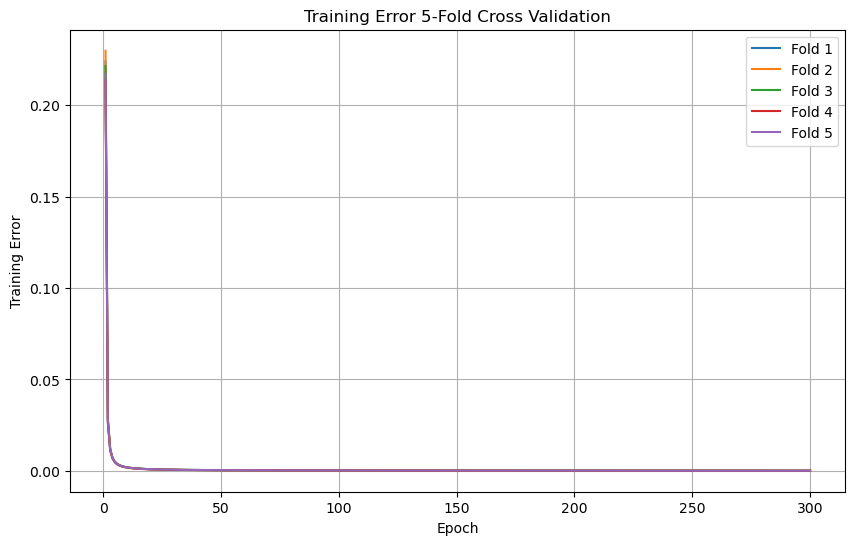

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(range(1, 301), plot_error1, label='Fold 1')
plt.plot(range(1, 301), plot_error2, label='Fold 2')
plt.plot(range(1, 301), plot_error3, label='Fold 3')
plt.plot(range(1, 301), plot_error4, label='Fold 4')
plt.plot(range(1, 301), plot_error5, label='Fold 5')

plt.xlabel('Epoch')
plt.ylabel('Training Error')
plt.title('Training Error 5-Fold Cross Validation')
plt.legend()
plt.grid(True)
plt.show()